# 预测性维护：无监督学习（聚类）

本 Notebook 使用同一个 Kaggle 数据集，但**不使用故障标签来训练**，
而是用 **K-Means 聚类** 探索数据中是否存在自然的「分组结构」，
再用已有的真实故障类型（`Failure Type`）评估聚类结果的质量。

参考资料：
https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

## 整体思路

监督学习（上一个 Notebook）直接用标签训练模型；而无监督学习**不使用标签**，
只根据特征之间的相似性把样本分成若干「簇（cluster）」。

本 Notebook 的做法是：

1. 先像监督学习一样对特征做标准化 / 独热编码；
2. 用 **K-Means** 把样本聚成 k=6 个簇（因为真实故障类型有 6 种）；
3. 拿我们手上已有的真实标签，评估聚类结构与真实类别的一致程度。

In [2]:
path = "predictive_maintenance.csv"
df = pd.read_csv(path)
print(df.shape)                   # (10000, 10)
df.head()

(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


> 说明：这份数据里有两个标签列 —— `Target`（二分类：正常 / 故障）和
> `Failure Type`（更细的故障类型，共 6 类）。本 Notebook 以 `Failure Type`
> 作为参照标签，用来观察聚类结果是否与真实的故障类型对应。

In [3]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
categorical_features = ["Type"]

X = df[numeric_features + categorical_features]
y = df['Failure Type']
# 类别分布很不均衡，先看一下
print(y.value_counts())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


In [4]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
0,298.1,308.6,1551,42.8,0,M
1,298.2,308.7,1408,46.3,3,L
2,298.1,308.5,1498,49.4,5,L
3,298.2,308.6,1433,39.5,7,L
4,298.2,308.7,1408,40.0,9,L


## 特征预处理

K-Means 基于欧氏距离。数值特征的量纲不同，因此需要标准化；
`Type` 是类别特征，先用独热编码转换为数值特征。

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features),
    ]
)
X_scaled = preprocessor.fit_transform(X)

In [6]:
X_scaled

array([[-0.95238944, -0.94735989,  0.06818514, ...,  0.        ,
         0.        ,  1.        ],
       [-0.90239341, -0.879959  , -0.72947151, ...,  0.        ,
         1.        ,  0.        ],
       [-0.95238944, -1.01476077, -0.22744984, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.50242514, -0.94735989,  0.59251888, ...,  0.        ,
         0.        ,  1.        ],
       [-0.50242514, -0.879959  , -0.72947151, ...,  1.        ,
         0.        ,  0.        ],
       [-0.50242514, -0.879959  , -0.2162938 , ...,  0.        ,
         0.        ,  1.        ]])

## K-Means 聚类

K-Means 的思想是：随机初始化 k 个「簇中心」，然后反复执行
「把每个样本分给最近的簇中心 → 用簇内样本均值更新簇中心」两步，直到收敛。

真实类别有 6 种，所以先试试 k=6。注意：K-Means 只知道“这是第 0~5 簇”，
簇编号和真实类别名没有任何对应关系，需要用交叉表人工对账。

In [7]:
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 交叉表：行 = 真实类别，列 = 聚类簇编号
pd.crosstab(y, clusters, rownames=["真实类别"], colnames=["簇编号"])


簇编号,0,1,2,3,4,5
真实类别,,,,,,
Heat Dissipation Failure,0,60,0,52,0,0
No Failure,1621,1529,2175,1636,791,1900
Overstrain Failure,0,50,0,0,0,28
Power Failure,0,24,16,14,31,10
Random Failures,1,5,0,6,1,5
Tool Wear Failure,9,17,0,0,6,13


## 用真实标签评估聚类效果

虽然训练没用标签，但既然我们有，就可以量化“聚类结构”与“真实类别”
的一致程度（注意：这与分类的准确率不是同一个概念）：

- **ARI（调整兰德指数）**：取值 [-1, 1]，1 表示完全一致，0 为随机水平。
- **同质性（Homogeneity）**：同一簇里的样本是否属于同一真实类别。
- **完整性（Completeness）**：同一真实类别的样本是否被分到同一簇。


In [8]:
print(f"ARI         : {adjusted_rand_score(y, clusters):.3f}")
print(f"同质性 Homog: {homogeneity_score(y, clusters):.3f}")
print(f"完整性 Compl: {completeness_score(y, clusters):.3f}")


ARI         : 0.002
同质性 Homog: 0.138
完整性 Compl: 0.016


## PCA 降维可视化

K-Means 是在标准化 + 独热编码后的高维特征上聚类的，无法直接画图。
这里用 **PCA** 把数据降到 2 维，方便观察聚类效果：

- 左图按真实类别着色，右图按聚类簇着色；
- 若两图着色分布相近，说明聚类结构大致符合真实类别。

最后一行打印按行归一化的交叉表，可以看到每个真实类别被分到哪个簇、比例多少。

输入数据形状：(10000, 8)
前两个主成分解释方差占比：67.7%


/tmp/ipykernel_24105/669977641.py:15: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/669977641.py:15: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/669977641.py:15: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/669977641.py:15: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/669977641.py:15: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/669977641.py:15: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/669977641.py:15: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from current font.
  plt.tight_l

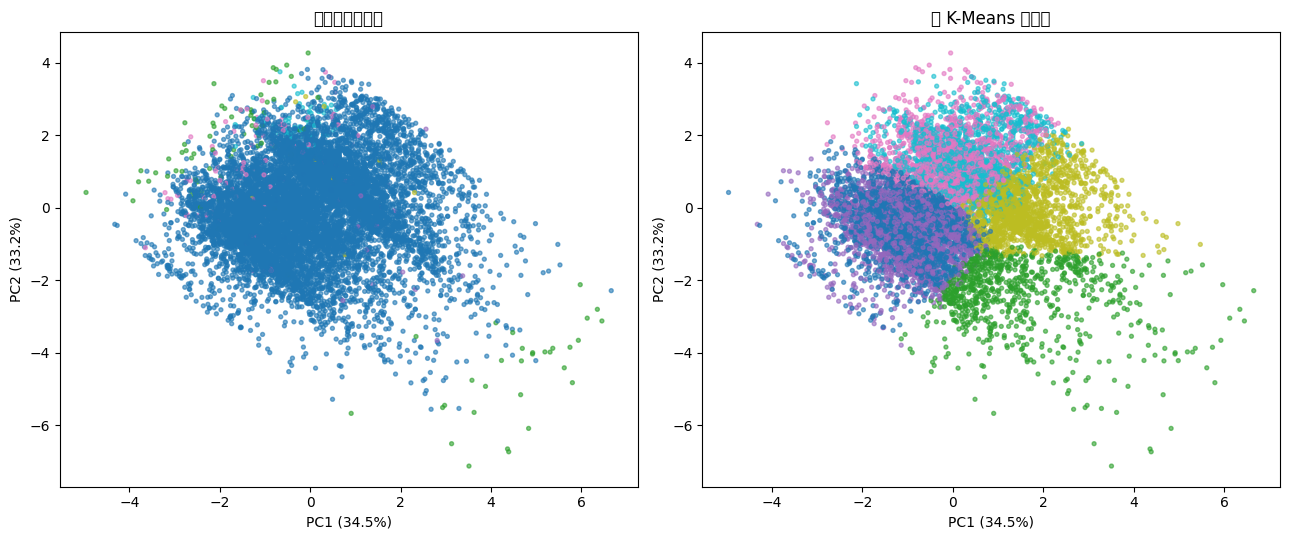

col_0                         0      1      2      3      4      5
Failure Type                                                      
Heat Dissipation Failure  0.000  0.536  0.000  0.464  0.000  0.000
No Failure                0.168  0.158  0.225  0.169  0.082  0.197
Overstrain Failure        0.000  0.641  0.000  0.000  0.000  0.359
Power Failure             0.000  0.253  0.168  0.147  0.326  0.105
Random Failures           0.056  0.278  0.000  0.333  0.056  0.278
Tool Wear Failure         0.200  0.378  0.000  0.000  0.133  0.289


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"输入数据形状：{X_scaled.shape}")
print(f"前两个主成分解释方差占比：{pca.explained_variance_ratio_.sum():.1%}")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, coloring, title in [
    (axes[0], y, "按真实类别着色"),
    (axes[1], clusters, "按 K-Means 簇着色"),
]:
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(coloring)[0],
                         s=8, alpha=0.6, cmap="tab10")
    ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
           ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", title=title)
plt.tight_layout()
plt.show()
print(pd.crosstab(y, clusters, normalize="index").round(3))

## ① 换成无监督异常检测（最推荐）

用 Isolation Forest / One-Class SVM / LOF 找出离群样本（≈故障），并用 Target（正常/故障）评估，而不是 Failure Type：

In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score

# X_scaled 复用你已有的预处理结果
iso = IsolationForest(n_estimators=200, contamination=0.034, random_state=42)
iso.fit(X_scaled)

# decision_function 越低越异常；取负号转成"异常分数"，越大越可能是故障
anomaly_score = -iso.decision_function(X_scaled)

# 用真实 Target（0=正常, 1=故障）评估
y_target = df["Target"]
print("ROC-AUC :", roc_auc_score(y_target, anomaly_score))
print("PR-AUC  :", average_precision_score(y_target, anomaly_score))

ROC-AUC : 0.7302037599703702
PR-AUC  : 0.09959714019201212


## ②复用监督学习里的特征工程

In [26]:
from sklearn.ensemble import RandomForestClassifier

# ===== 特征工程 =====
df_fe = df.copy()

# 1) 功率 ∝ 转矩 × 转速
df_fe["power"] = df_fe["Torque [Nm]"] * df_fe["Rotational speed [rpm]"]
# 2) 温差 = 过程温度 - 空气温度
df_fe["temp_diff"] = df_fe["Process temperature [K]"] - df_fe["Air temperature [K]"]
# 3) 单位转矩下的磨损量
df_fe["wear_per_torque"] = df_fe["Tool wear [min]"] / (df_fe["Torque [Nm]"] + 1e-6)
# 4) 转速 / 转矩比
df_fe["speed_torque_ratio"] = df_fe["Rotational speed [rpm]"] / (df_fe["Torque [Nm]"] + 1e-6)

extended_features = numeric_features + [
    "power",
    "temp_diff",
    "wear_per_torque",
    "speed_torque_ratio",
]

X_ext = df_fe[extended_features + categorical_features]
X_ext.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],power,temp_diff,wear_per_torque,speed_torque_ratio,Type
0,298.1,308.6,1551,42.8,0,66382.8,10.5,0.000000,36.238317,M
1,298.2,308.7,1408,46.3,3,65190.4,10.5,0.064795,30.410367,L
2,298.1,308.5,1498,49.4,5,74001.2,10.4,0.101215,30.323886,L
3,298.2,308.6,1433,39.5,7,56603.5,10.4,0.177215,36.278480,L
4,298.2,308.7,1408,40.0,9,56320.0,10.5,0.225000,35.199999,L


In [29]:
preprocessor_ext = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), extended_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
X_ext_scaled = preprocessor_ext.fit_transform(X_ext)


In [39]:

# X_ext_scaled 复用你已有的预处理结果
iso_ext = IsolationForest(n_estimators=200, contamination=0.034, random_state=42)
iso_ext.fit(X_ext_scaled)

# decision_function 越低越异常；取负号转成"异常分数"，越大越可能是故障
score_iso = -iso_ext.decision_function(X_ext_scaled)

# 用真实 Target（0=正常, 1=故障）评估
y_target = df["Target"]
print(f"\n===== iso =====")
print("ROC-AUC :", roc_auc_score(y_target, score_iso))
print("PR-AUC  :", average_precision_score(y_target, score_iso))


===== iso =====
ROC-AUC : 0.7871287990304967
PR-AUC  : 0.14969191099952459


## 换/组合检测器，对这类重叠数据通常比单用 Isolation Forest 好

In [40]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(X_scaled)
score_lof = -lof.score_samples(X_scaled)

# 用真实 Target（0=正常, 1=故障）评估
y_target = df["Target"]
print(f"\n===== lof =====")
print("ROC-AUC :", roc_auc_score(y_target, score_lof))
print("PR-AUC  :", average_precision_score(y_target, score_lof))

ocsvm = OneClassSVM(nu=0.05, gamma="scale")
ocsvm.fit(X_scaled)
score_ocsvm = -ocsvm.score_samples(X_scaled)

# 用真实 Target（0=正常, 1=故障）评估
y_target = df["Target"]
print(f"\n===== ocsvm =====")
print("ROC-AUC :", roc_auc_score(y_target, score_ocsvm))
print("PR-AUC  :", average_precision_score(y_target, score_ocsvm))

# 把三个分数取平均（先各自 min-max 归一化再平均）往往更稳


===== lof =====
ROC-AUC : 0.8048166166373392
PR-AUC  : 0.17866404323232066

===== ocsvm =====
ROC-AUC : 0.7717187890734849
PR-AUC  : 0.2284166167640463


### 把三个检测器「集成」（最推荐，通常还能再涨）

In [42]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

# score_lof / score_ocsvm / score_iso 分别是三个模型的异常分数（越大越异常）
score_ensemble = (
    normalize(score_lof) + normalize(score_ocsvm) + normalize(score_iso)
) / 3

from sklearn.metrics import roc_auc_score, average_precision_score
y_target = df["Target"]
print("Ensemble ROC-AUC:", roc_auc_score(y_target, score_ensemble))
print("Ensemble PR-AUC :", average_precision_score(y_target, score_ensemble))

Ensemble ROC-AUC: 0.8155036870866321
Ensemble PR-AUC : 0.21962075488806368


/tmp/ipykernel_24105/2499037993.py:39: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/2499037993.py:39: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/2499037993.py:39: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/2499037993.py:39: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/2499037993.py:39: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/2499037993.py:39: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24105/2499037993.py:39: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from current font.
  plt.

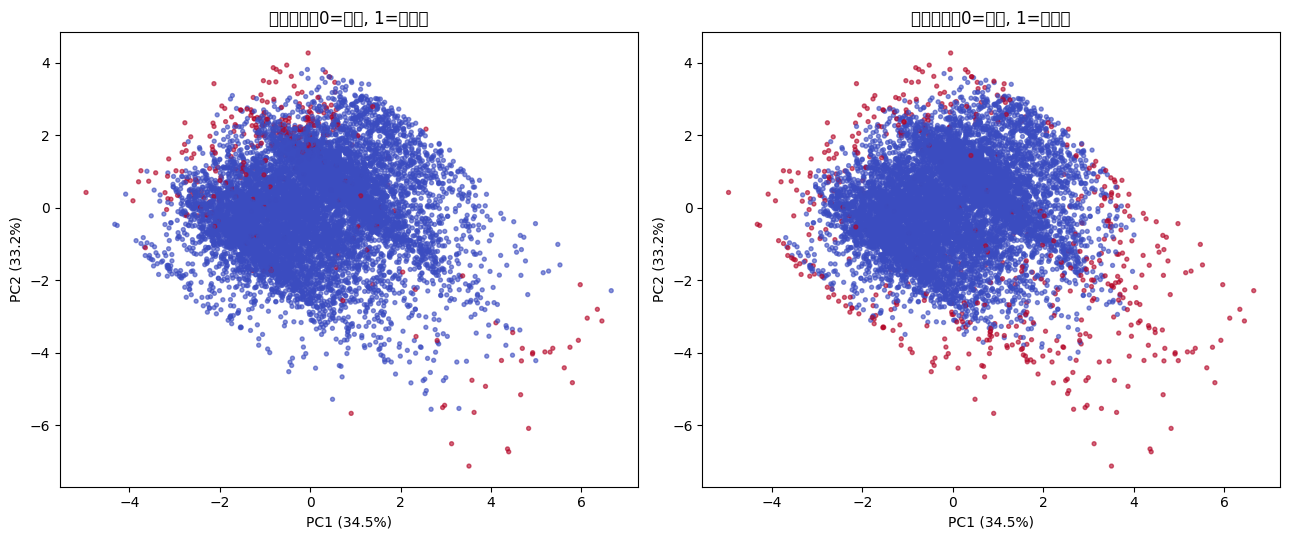

ROC-AUC : 0.787
PR-AUC  : 0.150


In [45]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score

# 1) 集成三个检测器的异常分数（越大越异常）
def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

score_ensemble = (
    normalize(score_lof) + normalize(score_ocsvm) + normalize(score_iso)
) / 3

y_target = df["Target"]

# 2) 按阈值得到预测标签：分数最高的 5% 判为异常
th = np.quantile(score_ensemble, 1 - 0.05)
pred = (score_ensemble >= th).astype(int)

# 3) 重新 PCA 到 2 维（确保用的是当前特征工程后的 X_scaled）
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# 左图：真实标签（0=正常，1=故障）
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_target,
                s=8, alpha=0.6, cmap="coolwarm", vmin=0, vmax=1)
axes[0].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
            ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
            title="真实标签（0=正常, 1=故障）")

# 右图：预测标签（异常检测结果）
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=pred,
                s=8, alpha=0.6, cmap="coolwarm", vmin=0, vmax=1)
axes[1].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
            ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
            title="预测标签（0=正常, 1=异常）")

plt.tight_layout()
plt.show()

# 数字验证
print(f"ROC-AUC : {roc_auc_score(y_target, score_iso):.3f}")
print(f"PR-AUC  : {average_precision_score(y_target, score_iso):.3f}")